In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(550068, 12)
['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [2]:
print(df.shape)
df.info()

(550068, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [3]:
print(df['User_ID'].nunique())
print(df['Product_ID'].nunique())

5891
3631


In [4]:
print(df['Gender'].value_counts())
print("---")
print(df['Age'].value_counts())
print("---")
print(df['City_Category'].value_counts())
print("---")
print(df['Stay_In_Current_City_Years'].value_counts())
print("---")
print(df['Marital_Status'].value_counts())

Gender
M    414259
F    135809
Name: count, dtype: int64
---
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64
---
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64
---
Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64
---
Marital_Status
0    324731
1    225337
Name: count, dtype: int64


In [5]:
df.groupby('User_ID')['Gender'].nunique().value_counts()

Gender
1    5891
Name: count, dtype: int64

In [6]:
print(df['Purchase'].describe())

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64


In [7]:
customer_df = df.groupby('User_ID').agg(
    Total_Purchase=('Purchase', 'sum'),
    Avg_Purchase=('Purchase', 'mean'),
    Num_Transactions=('Purchase', 'count'),
    Gender=('Gender', 'first'),
    Age=('Age', 'first'),
    Occupation=('Occupation', 'first'),
    City_Category=('City_Category', 'first'),
    Stay_In_Current_City_Years=('Stay_In_Current_City_Years', 'first'),
    Marital_Status=('Marital_Status', 'first')
).reset_index()

print(customer_df.shape)
customer_df.head()

(5891, 10)


,User_ID,Total_Purchase,Avg_Purchase,Num_Transactions,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status
0,1000001,334093,9545.514286,35,F,0-17,10,A,2,0
1,1000002,810472,10525.610390,77,M,55+,16,C,4+,0
2,1000003,341635,11780.517241,29,M,26-35,15,A,3,0
3,1000004,206468,14747.714286,14,M,46-50,7,B,2,1
4,1000005,821001,7745.292453,106,M,26-35,20,A,1,1


In [8]:
print(customer_df.shape)

(5891, 10)


In [9]:
customer_df[['Total_Purchase', 'Avg_Purchase', 'Num_Transactions']].describe()

,Total_Purchase,Avg_Purchase,Num_Transactions
count,5.891000e+03,5891.000000,5891.000000
mean,8.650166e+05,9568.839914,93.374300
std,9.436445e+05,1890.087105,107.190049
min,4.668100e+04,2318.733333,6.000000
25%,2.376780e+05,8287.212366,26.000000
50%,5.212130e+05,9386.208333,54.000000
75%,1.119250e+06,10654.633199,117.000000
max,1.053691e+07,18577.893617,1026.000000


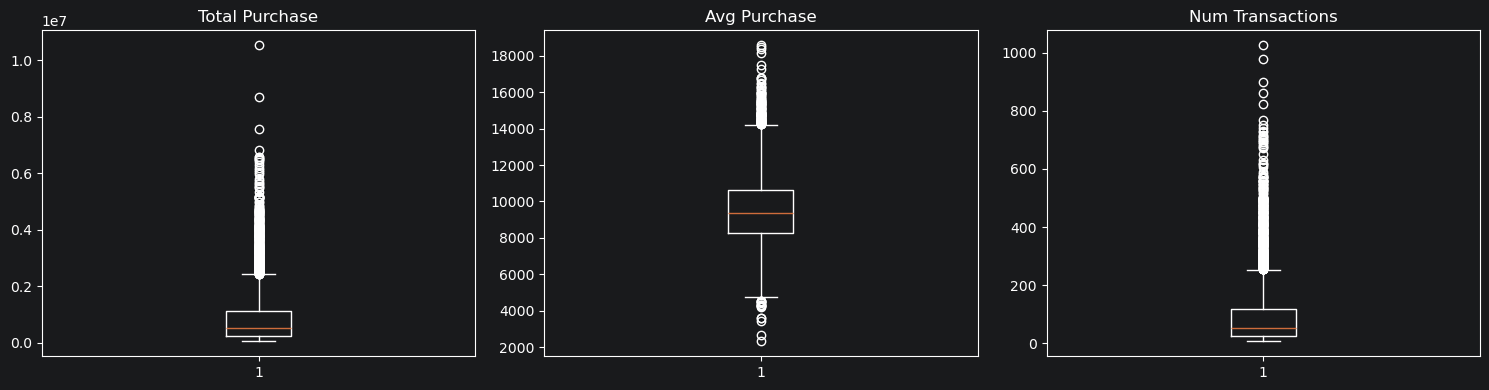

In [10]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.boxplot(customer_df['Total_Purchase'])
plt.title('Total Purchase')

plt.subplot(1, 3, 2)
plt.boxplot(customer_df['Avg_Purchase'])
plt.title('Avg Purchase')

plt.subplot(1, 3, 3)
plt.boxplot(customer_df['Num_Transactions'])
plt.title('Num Transactions')

plt.tight_layout()
plt.show()

In [11]:
print(customer_df['Gender'].value_counts())
print("---")
print(customer_df['Age'].value_counts())
print("---")
print(customer_df['City_Category'].value_counts())
print("---")
print(customer_df['Stay_In_Current_City_Years'].value_counts())
print("---")
print(customer_df['Marital_Status'].value_counts())

Gender
M    4225
F    1666
Name: count, dtype: int64
---
Age
26-35    2053
36-45    1167
18-25    1069
46-50     531
51-55     481
55+       372
0-17      218
Name: count, dtype: int64
---
City_Category
C    3139
B    1707
A    1045
Name: count, dtype: int64
---
Stay_In_Current_City_Years
1     2086
2     1145
3      979
4+     909
0      772
Name: count, dtype: int64
---
Marital_Status
0    3417
1    2474
Name: count, dtype: int64


In [12]:
print(customer_df['Age'].nunique())
print(customer_df['City_Category'].nunique())
print(customer_df['Stay_In_Current_City_Years'].nunique())
print(customer_df['Occupation'].nunique())

7
3
5
21
